In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load engineered features
train = pd.read_csv('../data/processed/train_features.csv',
                    index_col='date', parse_dates=True)
test  = pd.read_csv('../data/processed/test_features.csv',
                    index_col='date', parse_dates=True)

# Load scalers
scaler_X = joblib.load('../models/scaler_X.pkl')
scaler_y = joblib.load('../models/scaler_y.pkl')

# Load feature names
import json
with open('../models/feature_names.json', 'r') as f:
    feature_cols = json.load(f)

target_col = 'total_sales'

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
print('Features:', feature_cols)

Train shape: (1304, 13)
Test shape:  (15, 13)
Features: ['dcoilwtico', 'dayofweek', 'month', 'quarter', 'dayofyear', 'weekofyear', 'lag_7', 'lag_14', 'lag_30', 'lag_365', 'rolling_mean_7', 'rolling_mean_30']


In [2]:
# Sequence creation function + fixed splitting
TIMESTEPS = 7

def create_sequences(X, y, timesteps=7):
    """
    Converts flat feature arrays into
    3D sequences for LSTM input.
    """
    Xs, ys = [], []
    for i in range(timesteps, len(X)):
        Xs.append(X[i-timesteps:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# Combine train and test for proper sequencing
full_data = pd.concat([train, test])

X_full = scaler_X.transform(full_data[feature_cols])
y_full = scaler_y.transform(full_data[[target_col]])

# Create sequences on full dataset
X_seq, y_seq = create_sequences(X_full, y_full, TIMESTEPS)

# Split back into train and test
train_size   = len(train) - TIMESTEPS
X_train_seq  = X_seq[:train_size]
y_train_seq  = y_seq[:train_size]
X_test_seq   = X_seq[train_size:]
y_test_seq   = y_seq[train_size:]

print(f'X_train_seq shape: {X_train_seq.shape}')
print(f'X_test_seq shape:  {X_test_seq.shape}')
print(f'Test sequences: {len(X_test_seq)} (should be ~15)')

X_train_seq shape: (1297, 7, 12)
X_test_seq shape:  (15, 7, 12)
Test sequences: 15 (should be ~15)


In [3]:
# Build LSTM Model

def build_lstm(timesteps, n_features):
    """
    Builds a two-layer LSTM for time series forecasting.
    """
    model = Sequential([
        LSTM(64, return_sequences=True,
             input_shape=(timesteps, n_features)),
        Dropout(0.2),

        LSTM(32, return_sequences=False),
        Dropout(0.2),

        Dense(16, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_lstm(TIMESTEPS, len(feature_cols))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,673 (127.63 KB)

 Trainable params: 32,673 (127.63 KB)

 Non-trainable params: 0 (0.00 B)

Training LSTM...
Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0263 - mae: 0.1251 - val_loss: 0.0207 - val_mae: 0.1261
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0191 - mae: 0.1054 - val_loss: 0.0182 - val_mae: 0.1105
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0189 - mae: 0.1061 - val_loss: 0.0212 - val_mae: 0.1297
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0186 - mae: 0.1041 - val_loss: 0.0201 - val_mae: 0.1249
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0179 - mae: 0.1036 - val_loss: 0.0175 - val_mae: 0.0954
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0173 - mae: 0.1005 - val_loss: 0.0158 - val_mae: 0.0995
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0168 - mae: 0.0993 - val_loss: 0.0163 - val_mae: 0.1075
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0156 - mae: 0.0954 - val_loss: 0.0161 - val_mae: 0.1083
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - los

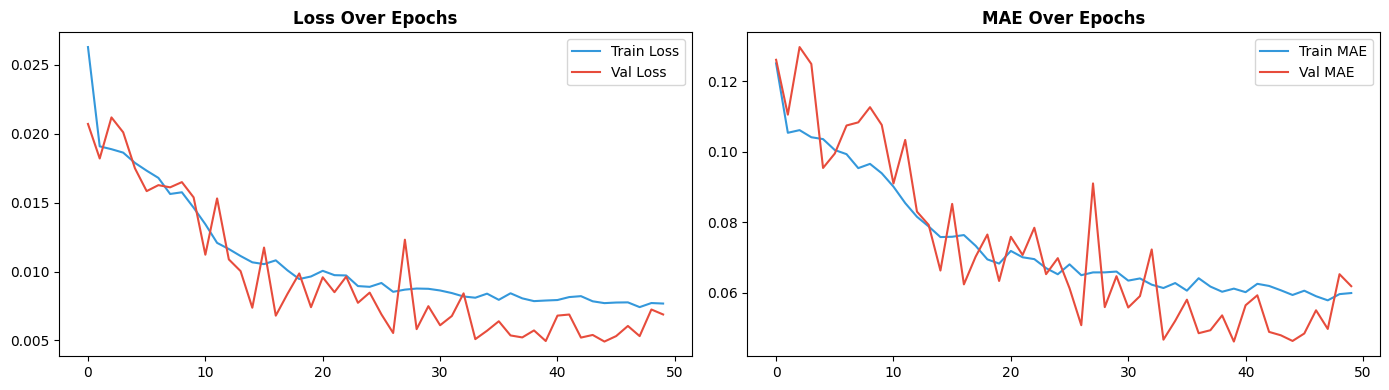

In [4]:
# Train LSTM

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print('Training LSTM...')
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)
print('Training complete!')

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],
             label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'],
             label='Val Loss', color='#e74c3c')
axes[0].set_title('Loss Over Epochs', fontweight='bold')
axes[0].legend()

axes[1].plot(history.history['mae'],
             label='Train MAE', color='#3498db')
axes[1].plot(history.history['val_mae'],
             label='Val MAE', color='#e74c3c')
axes[1].set_title('MAE Over Epochs', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/09_lstm_training.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Evaluate LSTM

# Generate predictions
y_pred_scaled = model.predict(X_test_seq)

# Inverse transform to real sales values
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test_seq)

mae  = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mape = np.mean(np.abs(
    (y_actual - y_pred) / y_actual)) * 100

print('=== LSTM Performance ===')
print(f'MAE:  {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'MAPE: {mape:.2f}%')

print(f'\n=== Full Model Comparison ===')
print(f'{"Model":<12} {"MAE":>8} {"RMSE":>8} {"MAPE":>8}')
print(f'{"─"*40}')
print(f'{"ARIMA":<12} {"1,706":>8} {"2,115":>8} {"24.8%":>8}')
print(f'{"Prophet":<12} {"1,325":>8} {"1,858":>8} {"18.9%":>8}')
print(f'{"LSTM":<12} {mae:>8,.0f} {rmse:>8,.0f} {mape:>8.1f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
=== LSTM Performance ===
MAE:  1,099.69
RMSE: 1,760.63
MAPE: 14.83%

=== Full Model Comparison ===
Model             MAE     RMSE     MAPE
────────────────────────────────────────
ARIMA           1,706    2,115    24.8%
Prophet         1,325    1,858    18.9%
LSTM            1,100    1,761     14.8%


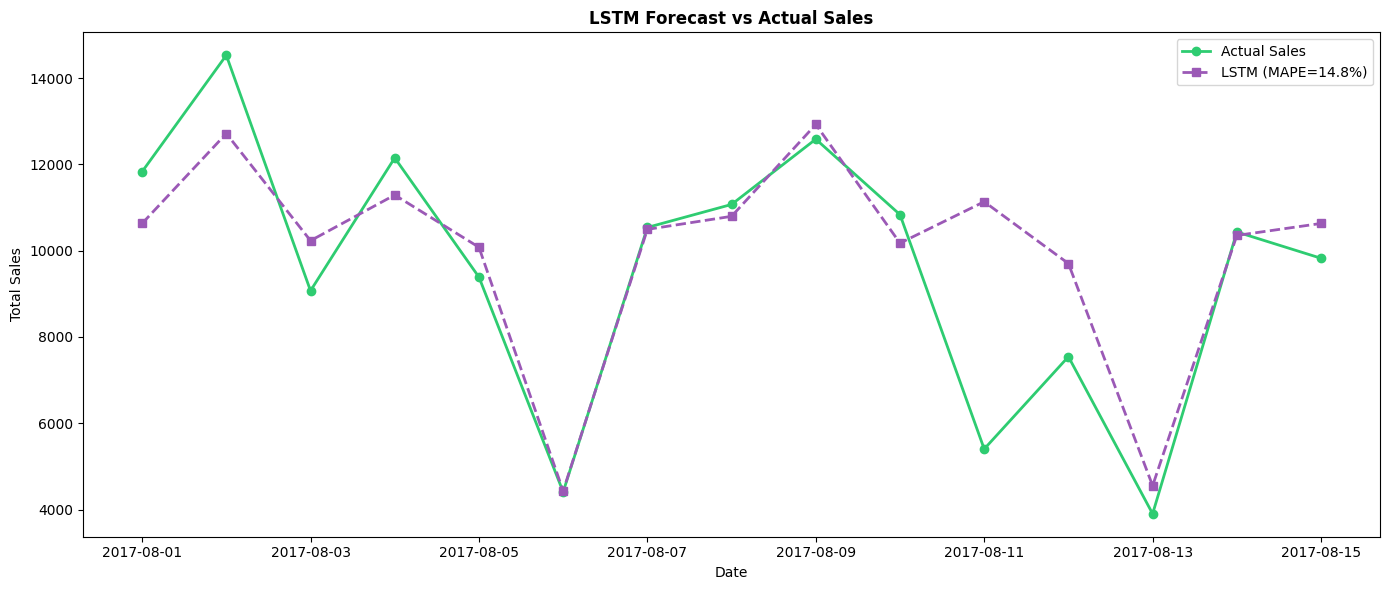

In [6]:
# Plot the LSTM Forecast

test_dates = test.index[:len(y_pred)]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_dates, y_actual,
        color='#2ecc71', linewidth=2,
        marker='o', label='Actual Sales')
ax.plot(test_dates, y_pred,
        color='#9b59b6', linewidth=2,
        marker='s', linestyle='--',
        label=f'LSTM (MAPE={mape:.1f}%)')

ax.set_title('LSTM Forecast vs Actual Sales',
             fontweight='bold')
ax.legend()
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
plt.tight_layout()
plt.savefig('../reports/figures/10_lstm_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()